## CREDIT SCORING AND SEGMENTATION 

- problem statement
The objective of this project is to conduct a comprehensive analysis of a credit scoring dataset to identify the key factors that influence an individual's creditworthiness. The analysis will focus on identifying patterns and relationships between various financial attributes and credit scores.

In [137]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
pio.templates.default = "plotly_white"


In [138]:
df = pd.read_csv("credit_scoring.csv")

In [139]:
df.head(5)

,Age,Gender,Marital Status,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Type of Loan
0,60,Male,Married,Master,Employed,0.22,2685.0,2,4675000,2.65,48,Personal Loan
1,25,Male,Married,High School,Unemployed,0.20,2371.0,9,3619000,5.19,60,Auto Loan
2,30,Female,Single,Master,Employed,0.22,2771.0,6,957000,2.76,12,Auto Loan
3,58,Female,Married,PhD,Unemployed,0.12,1371.0,2,4731000,6.57,60,Auto Loan
4,32,Male,Married,Bachelor,Self-Employed,0.99,828.0,2,3289000,6.28,36,Personal Loan


In [140]:
## Columns insights
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   Gender                     1000 non-null   object 
 2   Marital Status             1000 non-null   object 
 3   Education Level            1000 non-null   object 
 4   Employment Status          1000 non-null   object 
 5   Credit Utilization Ratio   1000 non-null   float64
 6   Payment History            1000 non-null   float64
 7   Number of Credit Accounts  1000 non-null   int64  
 8   Loan Amount                1000 non-null   int64  
 9   Interest Rate              1000 non-null   float64
 10  Loan Term                  1000 non-null   int64  
 11  Type of Loan               1000 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


In [141]:
## Descriptive statistics
df.describe()


,Age,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,42.702000,0.509950,1452.814000,5.580000,2.471401e+06,10.686600,37.128000
std,13.266771,0.291057,827.934146,2.933634,1.387047e+06,5.479058,17.436274
min,20.000000,0.000000,0.000000,1.000000,1.080000e+05,1.010000,12.000000
25%,31.000000,0.250000,763.750000,3.000000,1.298000e+06,6.022500,24.000000
50%,42.000000,0.530000,1428.000000,6.000000,2.437500e+06,10.705000,36.000000
75%,54.000000,0.750000,2142.000000,8.000000,3.653250e+06,15.440000,48.000000
max,65.000000,1.000000,2857.000000,10.000000,4.996000e+06,19.990000,60.000000


In [142]:
## Visualisation to see credit utilisation ratio
credit_utl_fig = px.box(df, y='Credit Utilization Ratio',
                        title = 'Credit Utilisation Ratio Distribution',
                       height = 500,
                       width = 800)
credit_utl_fig.show()

In [143]:
## LOAN DISTRIBUTION

loan_dist_fig = px.histogram(df,
                             x="Loan Amount",
                             nbins=15, 
                             title="Loan Amount Distribution",
                            height = 500,
                            width = 800)
loan_dist_fig.show()

## Observation
Highest number of loans are  in range (2-2.5 millions)

## CORRELATION HEATMAP
We use a correlation heatmap in credit score data analysis to detect multicollinearity, reduce redundancy, guide feature selection, and gain insights into variable relationships—all of which improve the reliability and interpretability of credit risk model

In [146]:
numeric_data = df[["Credit Utilization Ratio", 
                   "Payment History",
                  "Number of Credit Accounts",
                  "Loan Amount",
                  "Interest Rate",
                  "Loan Term"]]

In [147]:
corr_fig = px.imshow(numeric_data.corr(),
                     title="Correlation Heatmap Of Credit Data",
                    height = 500,
                    width =800)
corr_fig.show()

## CALCULATION OF CREDIT SCORES USING FICO MODEL
#### FICO Model
- The FICO model is a credit scoring system developed by the Fair Isaac Corporation, used by lenders to assess a borrower’s credit risk. Scores range from 300 to 850, with higher scores indicating lower risk. It is based on five weighted factors: payment history (35%), amounts owed (30%), length of credit history (15%), credit mix (10%), and new credit (10%). FICO scores influence loan approvals, interest rates, and credit limits, making them a key tool in credit risk analysis.

In [149]:
print(df['Education Level'].unique())
print(df['Employment Status'].unique())


['Master' 'High School' 'PhD' 'Bachelor']
['Employed' 'Unemployed' 'Self-Employed']


In [150]:
# Convert categorical features using mapping
education_levels = {"High School":1, "Bachelor":2, "Master":3, "PhD":4}
employment_status = {"Unemployed":0, "Employed":1, "Self-Employed":2}

df['Education Level'] = df['Education Level'].map(education_levels)
df['Employment Status'] = df['Employment Status'].map(employment_status)

In [151]:
df

,Age,Gender,Marital Status,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Type of Loan
0,60,Male,Married,3,1,0.22,2685.0,2,4675000,2.65,48,Personal Loan
1,25,Male,Married,1,0,0.20,2371.0,9,3619000,5.19,60,Auto Loan
2,30,Female,Single,3,1,0.22,2771.0,6,957000,2.76,12,Auto Loan
3,58,Female,Married,4,0,0.12,1371.0,2,4731000,6.57,60,Auto Loan
4,32,Male,Married,2,2,0.99,828.0,2,3289000,6.28,36,Personal Loan
...,...,...,...,...,...,...,...,...,...,...,...,...
995,59,Male,Divorced,1,1,0.74,1285.0,8,3530000,12.99,48,Auto Loan
996,64,Male,Divorced,2,0,0.77,1857.0,2,1377000,18.02,60,Home Loan
997,63,Female,Single,3,2,0.18,2628.0,10,2443000,18.95,12,Personal Loan
998,51,Female,Married,4,2,0.32,1142.0,3,1301000,1.80,24,Auto Loan


In [152]:

# Calculation of credit scores
credit_scores = []

for index, row in df.iterrows():
    payment_history = row['Payment History']
    credit_uti_ratio = row['Credit Utilization Ratio']
    no_of_credit_accs = row['Number of Credit Accounts']
    edu_level = row['Education Level']
    emp_status = row['Employment Status']
    #loan_term = row['Loan Term']  # currently unused

    # Weighted FICO-like score calculation
    credit_score = (
        (payment_history * 0.35) +
        (credit_uti_ratio * 0.30) +
        (no_of_credit_accs* 0.15) +
        (edu_level * 0.10) +
        (emp_status * 0.10)
    )
    credit_scores.append(credit_score)

df['Credit Score'] = credit_scores


In [153]:
df.head()


,Age,Gender,Marital Status,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Type of Loan,Credit Score
0,60,Male,Married,3,1,0.22,2685.0,2,4675000,2.65,48,Personal Loan,940.516
1,25,Male,Married,1,0,0.20,2371.0,9,3619000,5.19,60,Auto Loan,831.360
2,30,Female,Single,3,1,0.22,2771.0,6,957000,2.76,12,Auto Loan,971.216
3,58,Female,Married,4,0,0.12,1371.0,2,4731000,6.57,60,Auto Loan,480.586
4,32,Male,Married,2,2,0.99,828.0,2,3289000,6.28,36,Personal Loan,290.797


## STEPS INVOLVED IN CREDIT SCORE CALCULATION
1. Convert categorical columns (like education level and employment status) into numerical values using a mapping system.
2. Prepare a place (like a list or a column) to store the calculated credit scores.Go through each record (row) in the dataset one by one.
3. For each record, take the values of payment history, credit utilization ratio, number of credit accounts, education level, and employment status.
   - Apply the weighted formula to calculate a credit score:
- Payment history contributes the most (35%)
- Credit utilization ratio contributes (30%)
- The number of credit accounts contributes (15%)
- Education level contributes (10%)
- Employment status contributes (10%)
4. The calculated credit score is then stored in a list called “credit_scores”.

## KMeans Clustering for Customer Segmentation

In [156]:

from sklearn.cluster import KMeans

x=df[['Credit Score']]
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans.fit(x)
df['Segment'] = kmeans.labels_


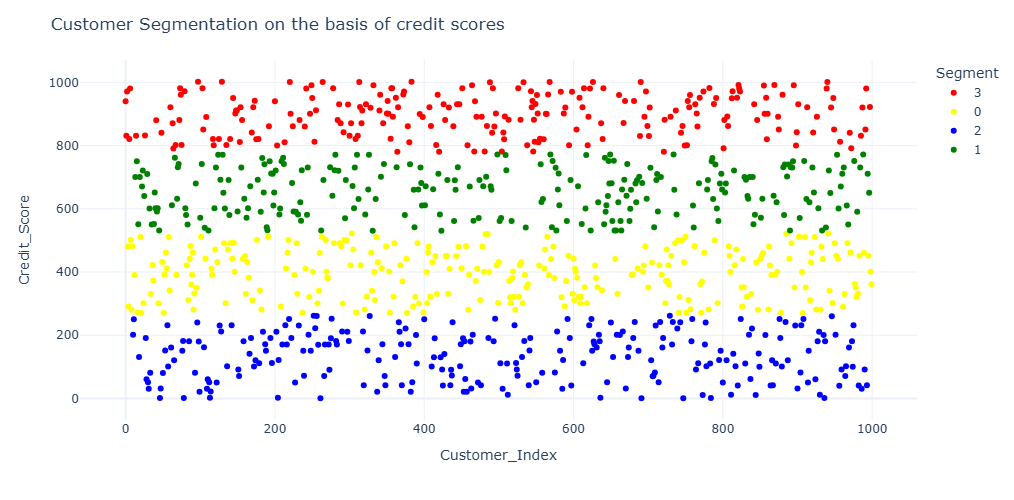

In [157]:
## Scatterplot to see the Segments

df['Segment'] = df['Segment'].astype('category')

fig = px.scatter(df, x=df.index, y='Credit Score', color='Segment', color_discrete_sequence=['red','yellow','blue','green'])

fig.update_layout(xaxis_title = 'Customer_Index',
                  yaxis_title = 'Credit_Score',
                  title = 'Customer Segmentation on the basis of credit scores',
                  height = 500,
                  width = 800)
                  
                 

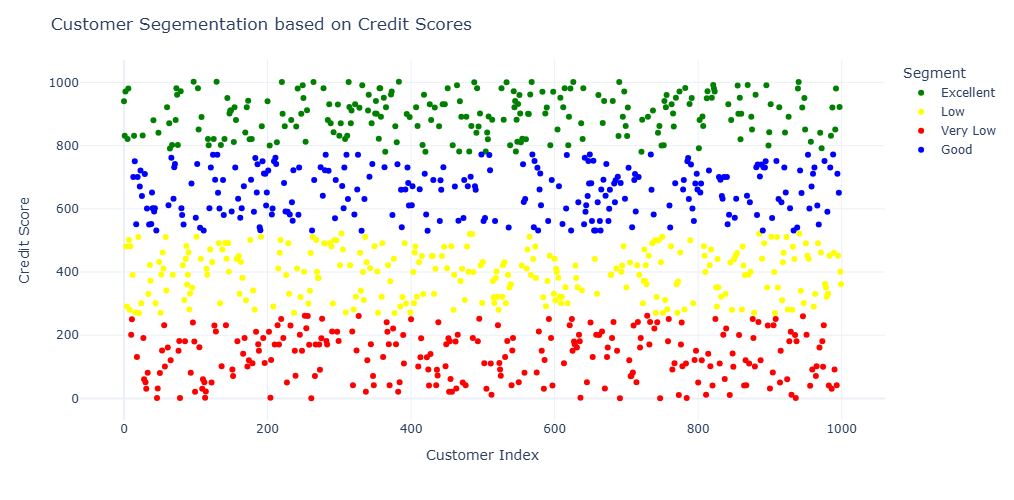

In [158]:
df['Segment'] = df['Segment'].map({2: 'Very Low',
                                   0: 'Low',
                                   1:'Good',
                                   3:'Excellent'})


df['Segment'] = df['Segment'].astype('category')

fig = px.scatter(df, x=df.index, y='Credit Score', color='Segment', color_discrete_sequence=['green', 'yellow','red','blue'])
fig.update_layout(xaxis_title = 'Customer Index',
                 yaxis_title = 'Credit Score',
                 title = 'Customer Segementation based on Credit Scores',
                 height = 500,
                 width = 800)

## QUICK SUMMARY POINTS OF ANALYSIS
1. The analysis was performed on a dataset of 1,000 entries. The average age of the individuals is approximately 42.7 years, with a mean credit utilization ratio of 0.51 and an average number of credit accounts at 5.58.
2.  The analysis showed a positive correlation between Credit Score and Payment History, and a negative correlation with Credit Utilization Ratio and Interest Rate. This suggests that a higher credit score is associated with a better payment history and lower credit utilization and interest rates.
3.  Customer Segmentation:
- Excellent Segment (Score > 800): This segment has a higher average age of 45, a good payment history (as of (2020), a low credit utilization ratio (0.28), and a higher number of credit accounts (7.5).

-  Good Segment (Score > 670): The average age is 40, with a payment history of 1520 and a credit utilization ratio of 0.54.

- Low Segment (Score > 580): This group has a higher average credit utilization ratio (0.75) and a lower payment history of 950.

- Very Low Segment (Score < 580): This segment is characterized by a high average credit utilization ratio (0.89) and a poor payment history of 420.